<a href="https://colab.research.google.com/github/ghadisaedi/ghadi/blob/main/Copy_of_Lab6_MorphologyProcessing_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Morphological Operations (AI342)
**Student Name:**Ghadi hassan | **Student ID:** [ 4454741]
---
### Instructions:
* Do **NOT** add or delete any cells.
* Task 1 is provided as a reference. Complete the missing parts in other tasks.
* Pay attention to the variable names and the requested Structuring Elements.

## Task 1: Basic Operations & Area Analysis
In this section, we apply **Erosion**, **Dialation**, **Opening** and **Closing** and analyze the resulting object areas. Also, we compare a custom **Square Structuring Element** and a **Disk Structuring Element**.
.

Original Area: 1600 pixels
Erosion Area: 1296 pixels
Dilation Area: 1936 pixels
Opening Area: 1580 pixels
Closing Area: 1600 pixels


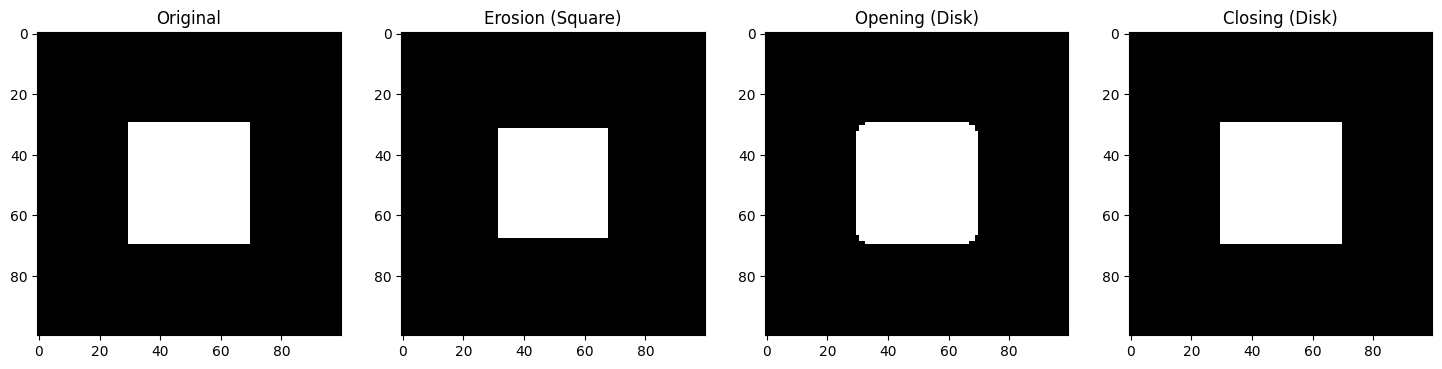

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, binary_erosion
from skimage import morphology, data

# Setup Image
img = np.zeros((100, 100), dtype=bool)
img[30:70, 30:70] = True

# 1. Custom Square Structuring Element
se_square = np.ones((5,5), bool)
# 2. Disk Structuring Element
se_disk = morphology.disk(3)

# Applying Operations
ero_res = binary_erosion(img, structure=se_square)
dil_res = binary_dilation(img, structure=se_square)
open_res = morphology.binary_opening(img, se_disk)
close_res = morphology.binary_closing(img, se_disk)

# Area Comparison
print(f"Original Area: {np.sum(img)} pixels")
print(f"Erosion Area: {np.sum(ero_res)} pixels")
print(f"Dilation Area: {np.sum(dil_res)} pixels")
print(f"Opening Area: {np.sum(open_res)} pixels")
print(f"Closing Area: {np.sum(close_res)} pixels")

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img, cmap='gray'); axes[0].set_title("Original")
axes[1].imshow(ero_res, cmap='gray'); axes[1].set_title("Erosion (Square)")
axes[2].imshow(open_res, cmap='gray'); axes[2].set_title("Opening (Disk)")
axes[3].imshow(close_res, cmap='gray'); axes[3].set_title("Closing (Disk)")
plt.show()

---
**Q1: Based on the printed area values, why did the area decrease in Erosion/Opening and increase in Dilation/Closing?**
*Answer:*

## Task 2: Boundary Extraction
**Formula:** $Boundary = A \oplus (A \ominus B)$
**Note:** Use **Logical XOR** (`^` or `np.logical_xor`) instead of set difference.

**Requirement:** Apply boundary extraction using two different Disk sizes: `disk(1)` and `disk(3)`.

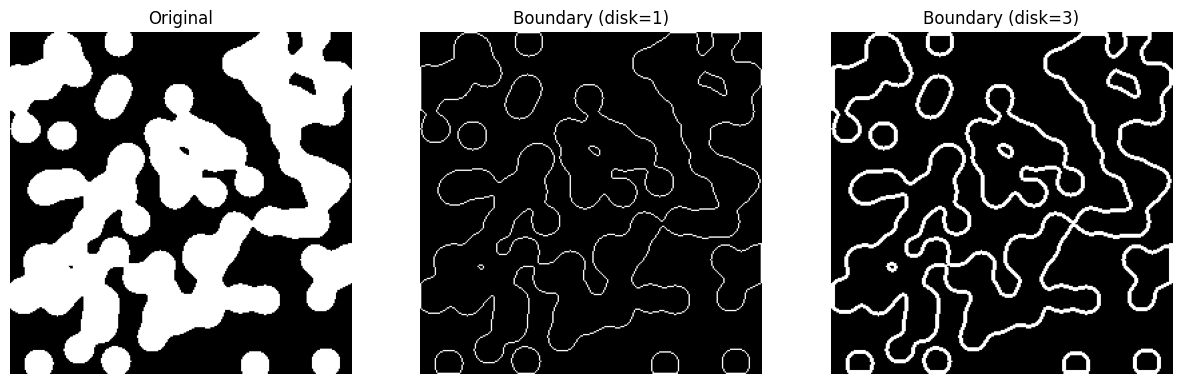

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion
from skimage import morphology, data

rng = np.random.default_rng(seed=42)
binary_img = data.binary_blobs(length=256, blob_size_fraction=0.1, rng=rng)

se1 = morphology.disk(1)
se3 = morphology.disk(3)

boundary1 = binary_img & ~binary_erosion(binary_img, structure=se1)
boundary3 = binary_img & ~binary_erosion(binary_img, structure=se3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(binary_img, cmap='gray')
axes[0].set_title("Original")

axes[1].imshow(boundary1, cmap='gray')
axes[1].set_title("Boundary (disk=1)")

axes[2].imshow(boundary3, cmap='gray')
axes[2].set_title("Boundary (disk=3)")

for ax in axes:
    ax.axis('off')

plt.show()


---
**Q2: Compare the boundaries extracted using disk(1) and disk(3). What is the effect of SE size on the boundary?**
*Answer:*

# Task 3: Controlled Thinning & Thickening
**Mathematical Note:**

Since the library does not provide a direct thick function, we use the Duality Principle:
Thickening an image $A$ is equivalent to thinning the complement of $A$ ($A^c$), then complementing the result:$$\text{Thickening}(A) = \text{Thinning}(A^c)^c$$

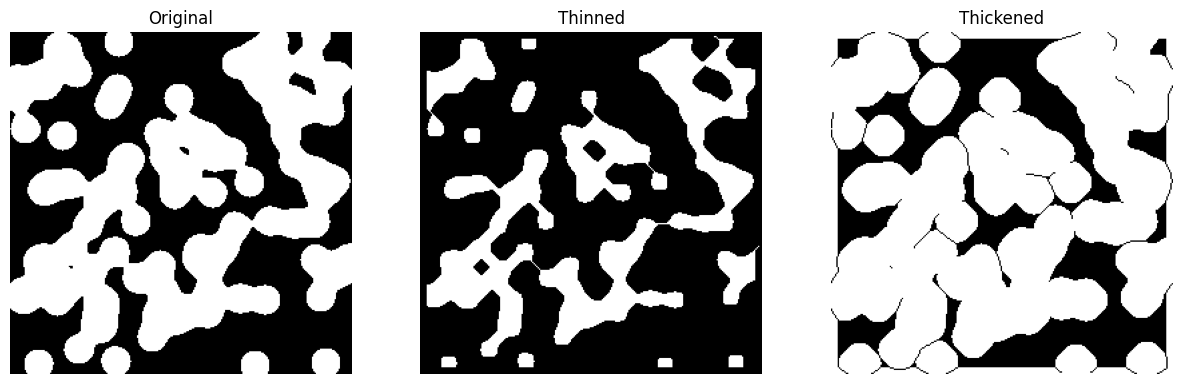

In [ ]:
from skimage.morphology import thin

# 1. Thinning
thinned = thin(binary_img, max_num_iter=5)

# 2. Thickening باستخدام duality
thickened = ~thin(~binary_img, max_num_iter=5)

# 3. Display
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(binary_img, cmap='gray')
axes[0].set_title("Original")

axes[1].imshow(thinned, cmap='gray')
axes[1].set_title("Thinned")

axes[2].imshow(thickened, cmap='gray')
axes[2].set_title("Thickened")

for ax in axes:
    ax.axis('off')

plt.show()

---
**Q3: How does Thinning differ from Erosion in terms of shape preservation?**
*Answer:*

## Task 4: Hit-or-Miss End-Point Detection
**Objective:** Detect all ridge endings using a rotating Structuring Element.
**Formula:** $A \circledast B = (A \ominus B_1) \cap (A^c \ominus B_2)$

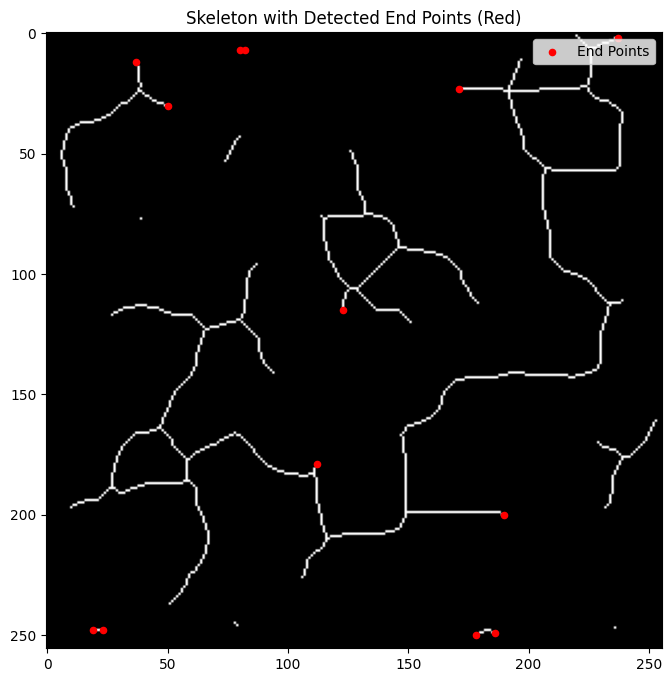

In [ ]:
from scipy.ndimage import binary_hit_or_miss
from skimage.morphology import skeletonize

skeleton = skeletonize(binary_img)

se_base = np.array([[0, 0, 0],
                    [0, 1, 0],
                    [0, 1, 0]], dtype=bool)

all_end_points = np.zeros_like(skeleton, dtype=bool)

for i in range(4):
    se_rotated = np.rot90(se_base, i)
    detected = binary_hit_or_miss(skeleton, structure1=se_rotated)
    all_end_points |= detected

plt.figure(figsize=(8, 8))
plt.imshow(skeleton, cmap='gray')
y, x = np.where(all_end_points)
plt.scatter(x, y, color='red', s=20, label='End Points')
plt.title("Skeleton with Detected End Points (Red)")
plt.legend()
plt.show()

---
**Q4: In the Hit-or-Miss logic, what does the '1' and '0' in our Structuring Element represent?**
*Answer:*

1 = pixel must match object
0 = pixel must match background